In [ ]:
import pandas as pd
import numpy as np

# Modeling association studies for MLSMR and Enzyme datasets

In [ ]:

mlsmr_perm = pd.read_csv('final_MLSMR_predictions_full_median.csv')
mlsmr = pd.read_excel('Prep notebook (Seigrist)_extra.xlsx', sheet_name = 'mlsmr')
mlsmr_activity = mlsmr['MTb (H37Rv) Primary Screen @ 10 uM: % Inhibition @ 10 uM (%)']

mlsmr_perm['MLSMR Predictions'] = mlsmr_perm['0']
mlsmr_perm = mlsmr_perm['MLSMR Predictions']

mlsmr_smiles = mlsmr['SMILES']



In [ ]:
import numpy as np
import pandas as pd
from scipy.stats import chi2_contingency

# the number of points for the bottom and top 15%
num_bottom_points = int(len(mlsmr_activity) * 0.15)
num_top_points = int(len(mlsmr_activity) * 0.15)

# Determining thresholds
sorted_activity = mlsmr_activity.sort_values()
bottom_activity_threshold = sorted_activity.iloc[num_bottom_points - 1]  # Bottom 15%
top_activity_threshold = sorted_activity.iloc[-num_top_points]          # Top 15%

# Filtering for points where activity is either in the bottom 15% or the top 15%
filtered_mlsmr = mlsmr[
    (mlsmr_activity <= bottom_activity_threshold) |
    (mlsmr_activity >= top_activity_threshold)
].copy()

# mean permeability threshold
perm_threshold = mlsmr_perm.mean()


# Lower numerical values → "High Permeability"
# Higher numerical values → "Low Permeability"
filtered_mlsmr['Permeability Category'] = np.where(
    filtered_mlsmr[mlsmr_perm.name] >= perm_threshold,
    'Low Permeability',
    'High Permeability'
)

# Bin activity into High and Low
filtered_mlsmr['Activity Category'] = np.where(
    filtered_mlsmr[mlsmr_activity.name] >= top_activity_threshold,
    'High Activity',
    'Low Activity'
)

# Verify the counts
num_bottom_points_actual = (mlsmr_activity <= bottom_activity_threshold).sum()
num_top_points_actual = (mlsmr_activity >= top_activity_threshold).sum()
print(f"Number of bottom activity points (<= {bottom_activity_threshold}): {num_bottom_points_actual}")
print(f"Number of top activity points (>= {top_activity_threshold}): {num_top_points_actual}")

# Create a contingency table
contingency_table_1 = pd.crosstab(filtered_mlsmr['Permeability Category'], filtered_mlsmr['Activity Category'])

# Perform the Chi-Squared Test
chi2_1, p_1, dof_1, expected_1 = chi2_contingency(contingency_table_1)

# Display results
print("\nContingency Table:")
print(contingency_table_1)

print("\nChi-Squared Test Results:")
print(f"Chi-Squared Statistic: {chi2_1:.4f}")
#print(f"P-Value: {p_1:.80f}")
print(f"P-Value: {p_1:.3e}")
print(f"Degrees of Freedom: {dof_1}")

print("\nExpected Frequencies:")
print(expected_1)

Number of bottom activity points (<= -6.74): 31938
Number of top activity points (>= 7.84): 31928

Contingency Table:
Activity Category      High Activity  Low Activity
Permeability Category                             
High Permeability              17562         14741
Low Permeability               14366         17197

Chi-Squared Test Results:
Chi-Squared Statistic: 499.9232
P-Value: 9.878e-111
Degrees of Freedom: 1

Expected Frequencies:
[[16148.9710331 16154.0289669]
 [15779.0289669 15783.9710331]]


In [ ]:
# Load the file
import numpy as np
import pandas as pd
from scipy.stats import chi2_contingency

df = pd.read_csv('final_enzyme_perm_full_median.csv')

# Inspect columns
print(df.columns)

# Step 1: Drop rows that are completely empty
df = df.dropna(how='all')

# Step 2: If only one column ('0') has extra NaNs — find and trim
# Count NaNs in each column
print(df.isna().sum())

# Step 3: Find the minimum number of non-null entries across key columns
min_len = min(df['Inhibition'].notna().sum(), df['0'].notna().sum())

# Step 4: Truncate to that min length
df_balanced = df[['SMILES', 'Inhibition', '0']].dropna().head(min_len).reset_index(drop=True)

# Step 5: Check alignment
print(df_balanced.head())

# Step 6: Save fixed version
df_balanced.to_csv('final_enzyme_perm_full_median.csv', index=False)


# ENZYME DATASET
df_balanced

print(df_balanced.shape)
df_balanced['Permeability'] = df_balanced['0']
enzyme_activity = df_balanced['Inhibition']
df_balanced['Activity'] = df_balanced['Inhibition']
enzyme_df = df_balanced.copy()

Index(['Unnamed: 0', 'SMILES', 'Inhibition', '0'], dtype='object')
Unnamed: 0    0
SMILES        4
Inhibition    4
0             4
dtype: int64
                                              SMILES  Inhibition         0
0    COC1=CC(=NC(=N1)NC(=O)COC(=O)C2=CC(=CC=C2)Cl)OC      511.75 -0.813102
1  CCN(CC)C1=CC2=C(C=C1)C(=C3C=CC(=[N+](CC)CC)C=C...      349.49 -2.125242
2  CN1C2=CC=CC3=C2C(=C(C1=O)NCCC4=CC=CC=C4)C5=CC=...      206.82 -2.125242
3  CCOC(=O)C1=CC=C(C=C1)NC(=O)C2=CN(N=C2C3=CC=NC=...      192.71 -2.125242
4  CC\1(C2=CC=CC=C2N(/C1=C\C=C\C3=[N+](C4=C(C3(C)...      186.64 -1.849021
(324854, 3)


In [ ]:
# Define the top 1% and bottom 1% thresholds
top_1_percentile = enzyme_activity.quantile(0.99)
bottom_1_percentile = enzyme_activity.quantile(0.01)

# Select High Activity Group (top 1%)
high_activity_df = enzyme_df[enzyme_activity >= top_1_percentile]

# Select Low Activity Group (bottom 1%)
low_activity_df = enzyme_df[enzyme_activity <= bottom_1_percentile]

# Combine the dataset
filtered_enzyme = pd.concat([high_activity_df, low_activity_df])

# Define Activity Categories
filtered_enzyme['Activity Category'] = np.where(
    filtered_enzyme['Activity'] >= top_1_percentile, 'High Activity', 'Low Activity'
)

perm_threshold = enzyme_df['Permeability'].mean()
filtered_enzyme['Permeability Category'] = np.where(
    filtered_enzyme['Permeability'] <= perm_threshold, 'High Permeability', 'Low Permeability'
)

# Verify Counts
num_high_activity = (filtered_enzyme['Activity'] >= top_1_percentile).sum()
num_low_activity = (filtered_enzyme['Activity'] <= bottom_1_percentile).sum()
print(f"Number of High Activity points (≥{top_1_percentile:.2f} - top 1%): {num_high_activity}")
print(f"Number of Low Activity points (≤{bottom_1_percentile:.2f} - bottom 1%): {num_low_activity}")

# Create Contingency Table
contingency_table_2 = pd.crosstab(filtered_enzyme['Permeability Category'], filtered_enzyme['Activity Category'])

# Perform Chi-Squared Test
chi2_2, p_2, dof_2, expected_2 = chi2_contingency(contingency_table_2)

# Display Results
print("\nContingency Table:")
print(contingency_table_2)

print("\nChi-Squared Test Results:")
print(f"Chi-Squared Statistic: {chi2_2:.4f}")
print(f"P-Value: {p_2:.10f}")
print(f"Degrees of Freedom: {dof_2}")

print("\nExpected Frequencies:")
print(expected_2)

Number of High Activity points (≥13.10 - top 1%): 3249
Number of Low Activity points (≤-45.21 - bottom 1%): 3249

Contingency Table:
Activity Category      High Activity  Low Activity
Permeability Category                             
High Permeability               1707          1655
Low Permeability                1542          1594

Chi-Squared Test Results:
Chi-Squared Statistic: 1.6030
P-Value: 0.2054719193
Degrees of Freedom: 1

Expected Frequencies:
[[1681. 1681.]
 [1568. 1568.]]


In [ ]:
# Sort by activity
sorted_df = enzyme_df.sort_values(by='Activity', ascending=True)

# Select bottom 157 (lowest activity)
low_activity_df = sorted_df.head(157)

# Select top 157 (highest activity)
high_activity_df = sorted_df.tail(157)

# Combine the two groups
filtered_enzyme = pd.concat([high_activity_df, low_activity_df], ignore_index=True)

# Assign Activity Category labels
filtered_enzyme['Activity Category'] = np.where(
    filtered_enzyme['Activity'] >= high_activity_df['Activity'].min(),
    'High Activity',
    'Low Activity'
)

# Permeability threshold (median)
perm_threshold = enzyme_df['Permeability'].mean()

filtered_enzyme['Permeability Category'] = np.where(
    filtered_enzyme['Permeability'] <= perm_threshold,
    'High Permeability',
    'Low Permeability'
)

# Verify counts
num_high_activity = (filtered_enzyme['Activity Category'] == 'High Activity').sum()
num_low_activity = (filtered_enzyme['Activity Category'] == 'Low Activity').sum()

print(f"Number of High Activity points (top 157): {num_high_activity}")
print(f"Number of Low Activity points (bottom 157): {num_low_activity}")

# Create Contingency Table
contingency_table_2 = pd.crosstab(
    filtered_enzyme['Permeability Category'],
    filtered_enzyme['Activity Category']
)

# Perform Chi-Squared Test
chi2_2, p_2, dof_2, expected_2 = chi2_contingency(contingency_table_2)

# Display Results
print("\nContingency Table:")
print(contingency_table_2)

print("\nChi-Squared Test Results:")
print(f"Chi-Squared Statistic: {chi2_2:.4f}")
print(f"P-Value: {p_2:.10f}")
print(f"Degrees of Freedom: {dof_2}")

print("\nExpected Frequencies:")
print(expected_2)


Number of High Activity points (top 157): 157
Number of Low Activity points (bottom 157): 157

Contingency Table:
Activity Category      High Activity  Low Activity
Permeability Category                             
High Permeability                 83            84
Low Permeability                  74            73

Chi-Squared Test Results:
Chi-Squared Statistic: 0.0000
P-Value: 1.0000000000
Degrees of Freedom: 1

Expected Frequencies:
[[83.5 83.5]
 [73.5 73.5]]


# Cramer V

In [ ]:
import numpy as np
from scipy.stats import chi2_contingency

def cramers_v(chi2, n, dof):
    min_dof = max(dof, 1)  # Ensure dof is at least 1
    return np.sqrt(chi2 / (n * min_dof))

# Dataset 1
chi2_1, p_1, dof_1, expected_1 = chi2_contingency(contingency_table_1)
n_1 = np.sum(contingency_table_1.values)
cramer_v_1 = cramers_v(chi2_1, n_1, dof_1)

# Dataset 2
chi2_2, p_2, dof_2, expected_2 = chi2_contingency(contingency_table_2)
n_2 = np.sum(contingency_table_2.values)
cramer_v_2 = cramers_v(chi2_2, n_2, dof_2)

# Print results
print(f"Dataset 1: Chi-Squared = {chi2_1:.2f}, Cramér's V = {cramer_v_1:.4f}")
print(f"Dataset 2: Chi-Squared = {chi2_2:.2f}, Cramér's V = {cramer_v_2:.4f}")

# Compare
if cramer_v_1 > cramer_v_2:
    print("Dataset 1 has a stronger association.")
elif cramer_v_1 < cramer_v_2:
    print("Dataset 2 has a stronger association.")
else:
    print("Both datasets have the same association strength.")


Dataset 1: Chi-Squared = 499.92, Cramér's V = 0.0885
Dataset 2: Chi-Squared = 1.60, Cramér's V = 0.0157
Dataset 1 has a stronger association.


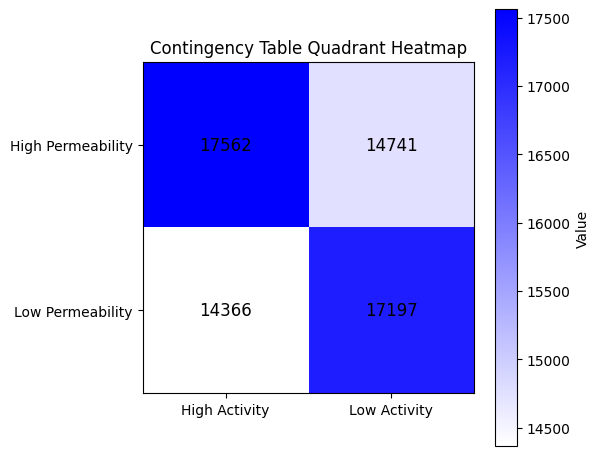

In [ ]:
#15
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import LinearSegmentedColormap

# Data for the new contingency table
data = np.array([[17562, 14741],
                 [14366, 17197]])

plt.figure(figsize=(6,5))

# Custom white → blue gradient colormap
cmap = LinearSegmentedColormap.from_list("white_to_blue", ["white", "blue"])

plt.imshow(data, cmap=cmap)

# Annotate numbers
for i in range(2):
    for j in range(2):
        plt.text(j, i, str(data[i, j]), ha='center', va='center', fontsize=12)

# Axis labels
plt.xticks([0,1], ["High Activity", "Low Activity"])
plt.yticks([0,1], ["High Permeability", "Low Permeability"])

plt.title("Contingency Table Quadrant Heatmap")
plt.colorbar(label="Value")

plt.tight_layout()
plt.show()


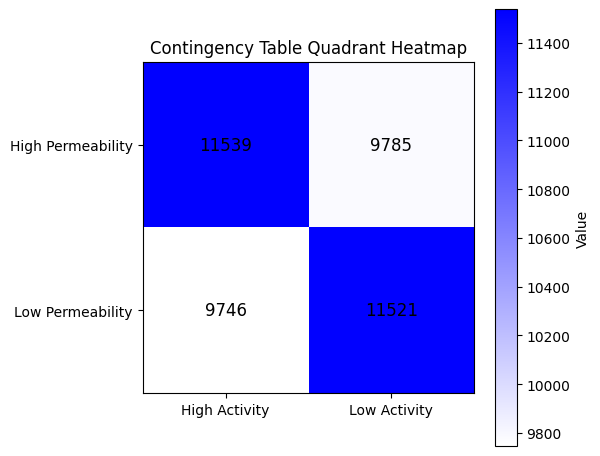

In [ ]:
# 10

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import LinearSegmentedColormap

# Data for the new contingency table
data = np.array([[11539, 9785],
                 [9746, 11521]])

plt.figure(figsize=(6,5))

# Custom white → blue gradient colormap
cmap = LinearSegmentedColormap.from_list("white_to_blue", ["white", "blue"])

plt.imshow(data, cmap=cmap)

# Annotate numbers
for i in range(2):
    for j in range(2):
        plt.text(j, i, str(data[i, j]), ha='center', va='center', fontsize=12)

# Axis labels
plt.xticks([0,1], ["High Activity", "Low Activity"])
plt.yticks([0,1], ["High Permeability", "Low Permeability"])

plt.title("Contingency Table Quadrant Heatmap")
plt.colorbar(label="Value")

plt.tight_layout()
plt.show()


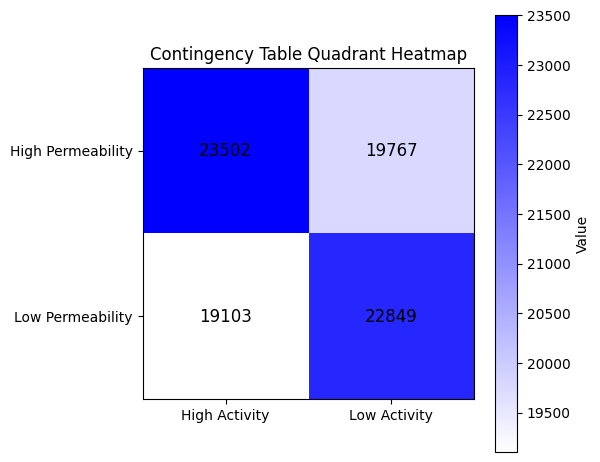

In [ ]:
# 20

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import LinearSegmentedColormap

# New contingency table data
data = np.array([[23502, 19767],
                 [19103, 22849]])

plt.figure(figsize=(6,5))

# White → Blue gradient colormap
cmap = LinearSegmentedColormap.from_list("white_to_blue", ["white", "blue"])

plt.imshow(data, cmap=cmap)

# Annotate cell values
for i in range(2):
    for j in range(2):
        plt.text(j, i, str(data[i, j]), ha='center', va='center', fontsize=12)

# Axis labels
plt.xticks([0,1], ["High Activity", "Low Activity"])
plt.yticks([0,1], ["High Permeability", "Low Permeability"])

plt.title("Contingency Table Quadrant Heatmap")
plt.colorbar(label="Value")

plt.tight_layout()
plt.show()


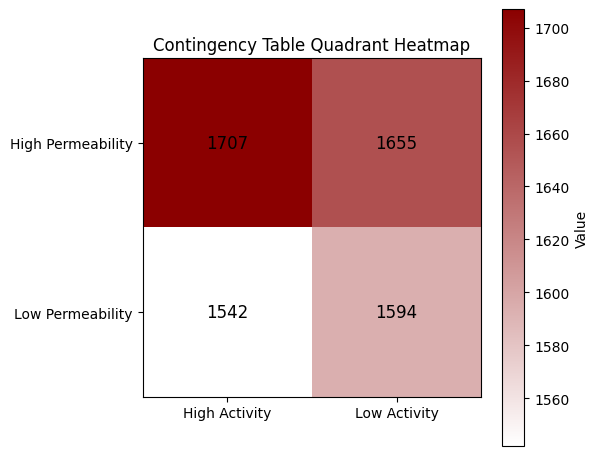

In [ ]:
# enzyme 1%
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import LinearSegmentedColormap

# Data for the contingency table
data = np.array([[1707, 1655],
                 [1542, 1594]])

plt.figure(figsize=(6,5))

# Custom white → brownish-red gradient colormap
cmap = LinearSegmentedColormap.from_list("white_to_redbrown", ["white", "#8B0000"])  # dark red/brownish

plt.imshow(data, cmap=cmap)

# Annotate cell values
for i in range(2):
    for j in range(2):
        plt.text(j, i, str(data[i, j]), ha='center', va='center', fontsize=12)

# Axis labels
plt.xticks([0,1], ["High Activity", "Low Activity"])
plt.yticks([0,1], ["High Permeability", "Low Permeability"])

plt.title("Contingency Table Quadrant Heatmap")
plt.colorbar(label="Value")

plt.tight_layout()
plt.show()


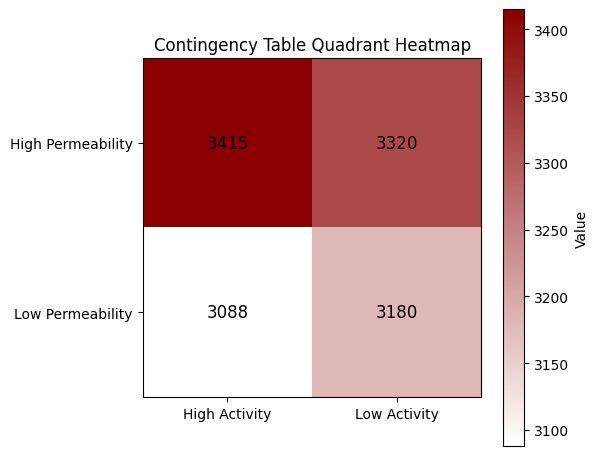

In [ ]:
# enzyme 2%

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import LinearSegmentedColormap

# Data for the contingency table
data = np.array([[3415, 3320],
                 [3088, 3180]])

plt.figure(figsize=(6,5))

# White → brownish-red gradient colormap (same as previous)
cmap = LinearSegmentedColormap.from_list("white_to_redbrown", ["white", "#8B0000"])

plt.imshow(data, cmap=cmap)

# Annotate cell values
for i in range(2):
    for j in range(2):
        plt.text(j, i, str(data[i, j]), ha='center', va='center', fontsize=12)

# Axis labels
plt.xticks([0,1], ["High Activity", "Low Activity"])
plt.yticks([0,1], ["High Permeability", "Low Permeability"])

plt.title("Contingency Table Quadrant Heatmap")
plt.colorbar(label="Value")

plt.tight_layout()
plt.show()


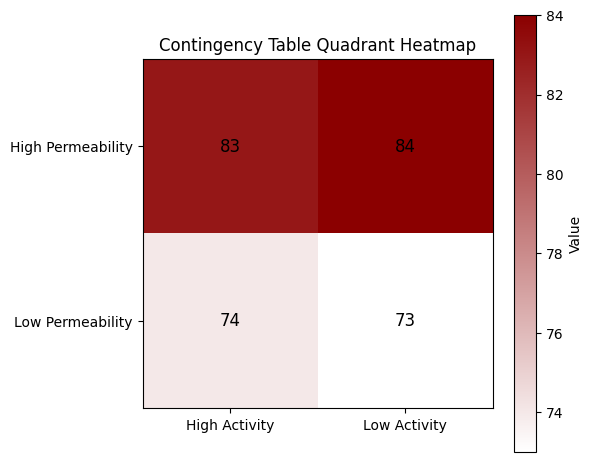

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import LinearSegmentedColormap

# Data for the contingency table
data = np.array([[83, 84],
                 [74, 73]])



plt.figure(figsize=(6,5))

# White → brownish-red gradient colormap
cmap = LinearSegmentedColormap.from_list("white_to_redbrown", ["white", "#8B0000"])

plt.imshow(data, cmap=cmap)

# Annotate cell values
for i in range(2):
    for j in range(2):
        plt.text(j, i, str(data[i, j]), ha='center', va='center', fontsize=12)

# Axis labels
plt.xticks([0,1], ["High Activity", "Low Activity"])
plt.yticks([0,1], ["High Permeability", "Low Permeability"])

plt.title("Contingency Table Quadrant Heatmap")
plt.colorbar(label="Value")

plt.tight_layout()
plt.show()


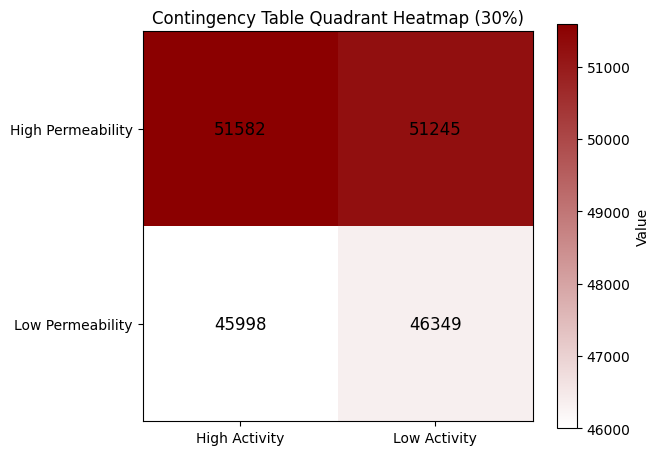

In [ ]:
#3 perecent
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns
# Number of High Activity points (≥10.01 - top 1%): 9768
# Number of Low Activity points (≤-19.85 - bottom 1%): 9751

# Contingency Table:
# Activity Category      High Activity  Low Activity
# Permeability Category
# High Permeability               5157          4968
# Low Permeability                4611          4783

# Chi-Squared Test Results:
# Chi-Squared Statistic: 6.5887
# P-Value: 0.0102628325
# Degrees of Freedom: 1

# Expected Frequencies:
# [[5066.90916543 5058.09083457]
#  [4701.09083457 4692.90916543]]

# Data for the contingency table
data = np.array([[51582, 51245],
                 [45998, 46349]])

# Contingency Table:
# Activity Category      High Activity  Low Activity
# Permeability Category
# High Permeability              51582         51245
# Low Permeability               45998         46349

# Contingency Table:
# Activity Category      High Activity  Low Activity
# Permeability Category
# High Permeability               5157          4968
# Low Permeability                4611          4783
# plt.figure(figsize=(6,5))

# White → brownish-red gradient colormap
cmap = LinearSegmentedColormap.from_list("white_to_redbrown", ["white", "#8B0000"])

plt.imshow(data, cmap=cmap)

# Annotate cell values
for i in range(2):
    for j in range(2):
        plt.text(j, i, str(data[i, j]), ha='center', va='center', fontsize=12)

# Axis labels
plt.xticks([0,1], ["High Activity", "Low Activity"])
plt.yticks([0,1], ["High Permeability", "Low Permeability"])

plt.title("Contingency Table Quadrant Heatmap (30%)")
plt.colorbar(label="Value")

plt.tight_layout()
plt.show()

In [ ]:
#

# Density plot

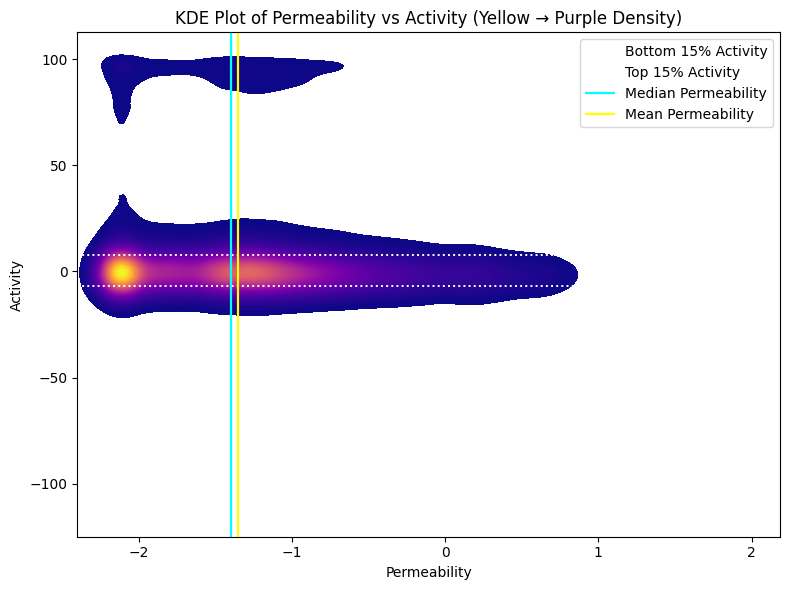

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# ----------------------------
# Calculate thresholds
# ----------------------------
activity_bottom_15 = np.percentile(mlsmr_activity, 15)
activity_top_15 = np.percentile(mlsmr_activity, 85)

perm_median = np.median(mlsmr_perm)
perm_mean = np.mean(mlsmr_perm)

# ----------------------------
# KDE Plot with Yellow→Purple Map
# ----------------------------
plt.figure(figsize=(8, 6))

sns.kdeplot(
    x=mlsmr_perm,
    y=mlsmr_activity,
    cmap="plasma",      # yellow → purple
    fill=True,
    thresh=0.05,
    levels=100
)

# ----------------------------
# Add threshold lines
# ----------------------------

# Activity 15% (horizontal dotted)
plt.axhline(activity_bottom_15, linestyle='dotted', color='white', linewidth=1.4,
            label='Bottom 15% Activity')
plt.axhline(activity_top_15, linestyle='dotted', color='white', linewidth=1.4,
            label='Top 15% Activity')

# Permeability median & mean (vertical)
plt.axvline(perm_median, linestyle='solid', color='cyan', linewidth=1.6,
            label='Median Permeability')
plt.axvline(perm_mean, linestyle='solid', color='yellow', linewidth=1.6,
            label='Mean Permeability')

# ----------------------------
# Labels & Presentation
# ----------------------------
plt.xlabel("Permeability")
plt.ylabel("Activity")
plt.title("KDE Plot of Permeability vs Activity (Yellow → Purple Density)")
plt.legend()

plt.tight_layout()
plt.show()


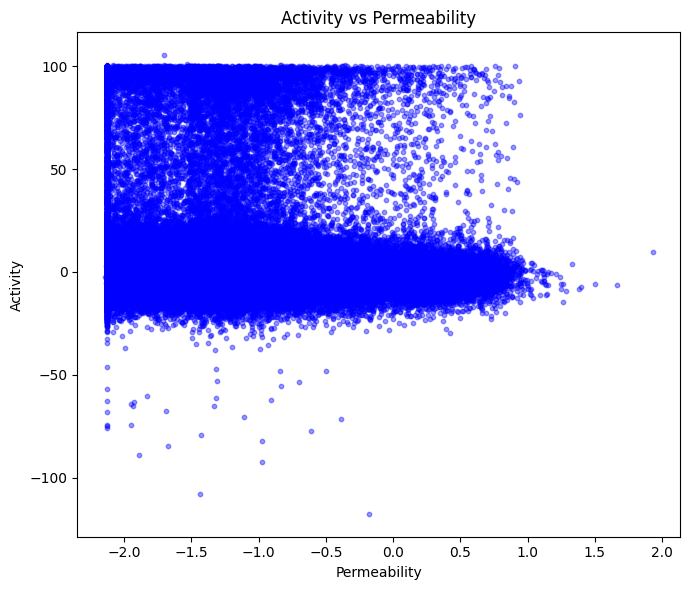

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,6))

plt.scatter(
    mlsmr_perm,
    mlsmr_activity,
    s=10,          # point size
    alpha=0.4,     # transparency so dense regions don’t saturate
    color="blue"
)

plt.xlabel("Permeability")
plt.ylabel("Activity")
plt.title("Activity vs Permeability")

plt.tight_layout()
plt.show()


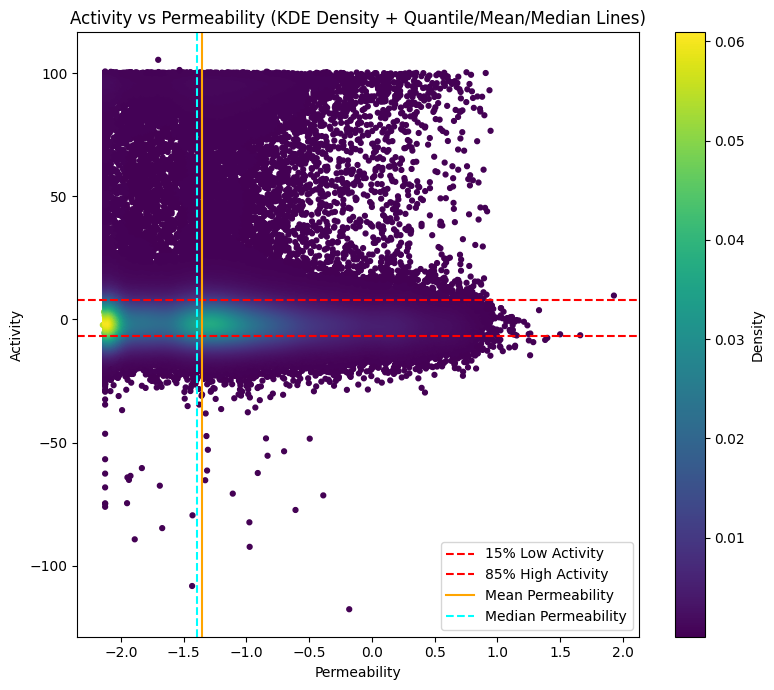

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import gaussian_kde

# Convert to numpy arrays
x = np.array(mlsmr_perm)      # Permeability
y = np.array(mlsmr_activity)  # Activity

# KDE
xy = np.vstack([x, y])
kde = gaussian_kde(xy)
density = kde(xy)

# Percentiles for activity
y_p15_low = np.percentile(y, 15)
y_p15_high = np.percentile(y, 85)

# Mean and median for permeability
x_mean = np.mean(x)
x_median = np.median(x)

plt.figure(figsize=(8,7))

# Density scatter
plt.scatter(x, y, c=density, s=12, cmap="viridis")

# Horizontal percentile lines
plt.axhline(y_p15_low, color="red", linestyle="--", linewidth=1.5, label="15% Low Activity")
plt.axhline(y_p15_high, color="red", linestyle="--", linewidth=1.5, label="85% High Activity")

# Mean & median vertical permeability lines
plt.axvline(x_mean, color="orange", linestyle="-", linewidth=1.5, label="Mean Permeability")
plt.axvline(x_median, color="cyan", linestyle="--", linewidth=1.5, label="Median Permeability")

plt.xlabel("Permeability")
plt.ylabel("Activity")
plt.title("Activity vs Permeability (KDE Density + Quantile/Mean/Median Lines)")
plt.colorbar(label="Density")
plt.legend()
plt.tight_layout()
plt.show()


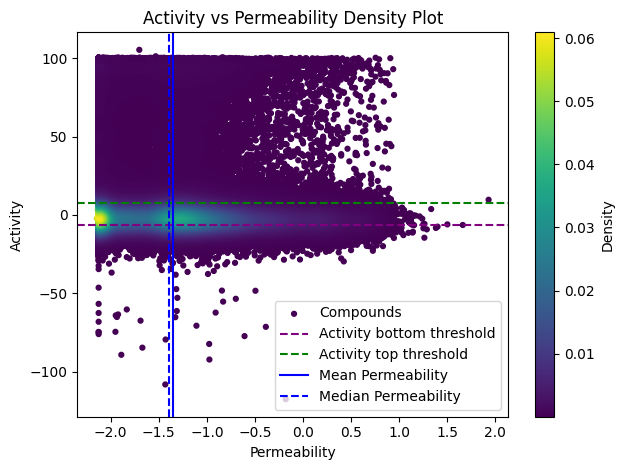

In [ ]:
# Density scatter
plt.scatter(x, y, c=density, s=12, cmap="viridis", label = "Compounds")

# Horizontal percentile lines
plt.axhline(y_p15_low, color="purple", linestyle="--", linewidth=1.5, label="Activity bottom threshold")
plt.axhline(y_p15_high, color="green", linestyle="--", linewidth=1.5, label="Activity top threshold")

# Mean & median vertical permeability lines
plt.axvline(x_mean, color="blue", linestyle="-", linewidth=1.5, label="Mean Permeability")
plt.axvline(x_median, color="blue", linestyle="--", linewidth=1.5, label="Median Permeability")

plt.xlabel("Permeability")
plt.ylabel("Activity")
plt.title("Activity vs Permeability Density Plot")
plt.colorbar(label="Density")
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:
plt.savefig('perm_vs_activity_density.png')

<Figure size 640x480 with 0 Axes>

In [ ]:
plt

<module 'matplotlib.pyplot' from '/usr/local/lib/python3.12/dist-packages/matplotlib/pyplot.py'>